In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import torch
from sklearn import metrics
from vBattNN import BattNN
import argparse
import copy

# reproducibility
random.seed(2022)
np.random.seed(2022)

class NPZData:
    def __init__(self, npz_dir='../../dataset/', n=50, length=50, date_fmt="%d-%b-%Y %H:%M:%S"):
        """
        npz_dir: folder containing run_XXX.npz files with arrays 'time','voltage','current','date'
        n:       how many runs to use for training
        length:  how many timesteps to crop each run to for train data
        date_fmt: format string for parsing the saved date field
        """
        self.npz_dir = npz_dir
        all_files = sorted(f for f in os.listdir(npz_dir)
                           if f.startswith('run_') and f.endswith('.npz'))
        admitted = []
        removed = []

        # 1) Filter out runs with any negative current
        for fname in all_files:
            data = np.load(os.path.join(npz_dir, fname))
            curr = np.asarray(data['current'])
            if np.any(curr < 0):
                removed.append(fname)
            else:
                admitted.append(fname)

        # Report removed runs
        if removed:
            print("Removed runs due to negative current:", removed)
        else:
            print("No runs removed due to negative current.")

        # 2) Parse date and sort admitted chronologically
        dated_files = []
        for fname in admitted:
            data = np.load(os.path.join(npz_dir, fname))
            date_str = str(data['date'].item())
            dt = datetime.strptime(date_str, date_fmt)
            dated_files.append((fname, dt))

        dated_files.sort(key=lambda x: x[1])
        sorted_files = [fname for fname, _ in dated_files]

        # 3) Split first n chronologically into train, rest into test
        self.train_files = sorted_files[:n]
        self.test_files  = sorted_files[n:]
        self.length      = length

    def load_train_data(self):
        """Return (I, V, dates) arrays for training."""
        I, V, D = [], [], []
        for fname in self.train_files:
            data = np.load(os.path.join(self.npz_dir, fname))
            curr = data['current'][:self.length].astype(np.float32)
            volt = data['voltage'][:self.length].astype(np.float32)
            date = str(data['date'].item())
            if curr.size == self.length and volt.size == self.length:
                I.append(curr)
                V.append(volt)
                D.append(date)
        return np.stack(I), np.stack(V), D

    def yield_test_data(self):
        """Yield (current, voltage, date) for each test run."""
        for fname in self.test_files:
            data = np.load(os.path.join(self.npz_dir, fname))
            curr = data['current'].astype(np.float32)
            volt = data['voltage'].astype(np.float32)
            date = str(data['date'].item())
            yield curr, volt, date


def look_up_data_with_dates(npz_dir='./data/'):
    """Show one test example with twin y-axes and date at x=0."""
    D = NPZData(npz_dir)
    train_x, train_y, train_dates = D.load_train_data()
    print("Train shapes:", train_x.shape, train_y.shape, "Dates:", train_dates)

    # one test run
    for c, v, d in D.yield_test_data():
        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()

        # current on left
        ax1.plot(c, color='g')
        ax1.set_ylabel('Current (A)', color='g')
        ax1.set_xticks([0])
        ax1.set_xticklabels([d], rotation=45, ha='right')

        # voltage on right
        ax2.plot(v, color='r')
        ax2.set_ylabel('Voltage (V)', color='r')

        fig.tight_layout()
        plt.show()
        break


def eval_metrics(y_true, y_pred):
    MAE  = metrics.mean_absolute_error     (y_true, y_pred)
    MAPE = metrics.mean_absolute_percentage_error(y_true, y_pred)
    MSE  = metrics.mean_squared_error      (y_true, y_pred)
    RMSE = np.sqrt(MSE)
    return [MAE, MAPE, MSE, RMSE]


def train(args, train_x, train_y, model_name='BattNN'):
    # 1) Create model
    if model_name == 'BattNN':
        model = BattNN(args)
        print("Selected model: BattNN")
    elif model_name == 'LSTM':
        model = LSTM(args)
        print("Selected model: LSTM")
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    print(f"Training on {train_x.shape[0]} runs")
    
    # 2) Package data into the model
    x_tensor = torch.from_numpy(train_x.astype(np.float32))
    y_tensor = torch.from_numpy(train_y.astype(np.float32))
    model.get_data(x=x_tensor, label=y_tensor)

    # 3) Train
    model.train()
    return model  # in case you want to keep it around


from joblib import Parallel, delayed
def mc_predict(model, current_seq, mc_samples=100, n_jobs=6):
    """
    Monte‐Carlo predict in parallel via joblib threads.
    
    Arguments:
      model       : your trained BattNN or LSTM
      current_seq : 1×T torch.Tensor of currents
      mc_samples  : how many stochastic forward‐passes
      n_jobs      : how many threads to use
      
    Returns:
      mean: (T,) np.array
      std:  (T,) np.array
    """
    device = next(model.parameters()).device

    # temporarily set all submodules to eval mode via the base class method
    base_train = torch.nn.Module.train
    # switch off training behaviors
    base_train(model, False)

    def sample_prediction():
        # each thread calls this
        with torch.no_grad():
            v_pred, _ = model.predict(current_seq)      # [1, T]
        return v_pred.cpu().numpy()[0]             # (T,)

    # Fire off mc_samples draws in parallel
    preds = Parallel(n_jobs=n_jobs)(
        delayed(sample_prediction)() 
        for _ in range(mc_samples)
    )
    stack = np.stack(preds, axis=0)  # shape = (mc_samples, T)

    # compute predictive mean
    mean = stack.mean(axis=0)
    # compute 2.5th and 97.5th percentiles
    lower = np.percentile(stack, 2.5, axis=0)
    upper = np.percentile(stack, 97.5, axis=0)
    
    return mean, lower, upper


def test(args, data_iter, model_name='BattNN', plot_n=5, mc_samples=100, n_jobs=6):
    """
    Evaluate a trained BattNN/LSTM on arbitrary‐length sequences, using Monte Carlo UQ.
    For each test run:
      1) Load checkpoint and slice init_x → batch_size=1
      2) Call mc_predict(...) to get (mean, lower, upper) of the predicted voltage
      3) Compute metrics on the mean prediction itself
      4) Plot (for up to plot_n runs) the current, true voltage, mean prediction, and 95% CI band
    
    Returns:
      mean_err:    (4,) list of average [MAE, MAPE, MSE, RMSE] over all test runs
      all_errors:  (num_runs, 4) array of per‐run metrics
    """
    # 1) Instantiate model and load checkpoint
    if model_name == 'BattNN':
        model = BattNN(args)
    elif model_name == 'LSTM':
        model = LSTM(args)
    else:
        raise ValueError(f"Unsupported model: {model_name}")
    model.load_model()                        # loads from results/...‐batch_size=…‐seq_len=….pkl

    # 2) For inference, we want batch_size=1 → slice off init_x:
    model.init_x = model.init_x[:1, :]        # keep only the first row (since every run is now one‐at‐a‐time)

    errors = [] 

    for i, (curr, volt, date) in enumerate(data_iter(), start=1):
        # 3) Build a [1 × T] tensor from the full‐length current trace
        c_t = torch.from_numpy(curr.astype(np.float32)).view(1, -1).to(args.device)

        # 4) Monte‐Carlo predict: get mean and 95% percentile CI
        mean_pred, lower_pred, upper_pred = mc_predict(
            model, c_t, mc_samples=mc_samples, n_jobs=n_jobs
        )
        # mean_pred, lower_pred, upper_pred are all numpy arrays of shape (T,)

        # 5) Compute metrics on the MEAN prediction
        met = eval_metrics(volt, mean_pred)   # [MAE, MAPE, MSE, RMSE]
        errors.append(met)

        # 6) Plot the first `plot_n` runs
        if i <= plot_n:
            T = volt.shape[0]
            t = np.arange(T)

            fig, ax1 = plt.subplots(figsize=(12, 8))
            ax2 = ax1.twinx()

            # Left y‐axis: current
            ax1.plot(t, curr, color='g', label='Current')
            ax1.set_ylabel('Current (A)', color='g')
            ax1.tick_params(axis='y', labelcolor='g')
            ax1.set_xticks([0])
            ax1.set_xticklabels([date], rotation=45, ha='right')

            # Right y‐axis: true voltage, mean, and CI band
            ax2.plot(t, volt,     '-r', label='Voltage (true)')
            ax2.plot(t, mean_pred,'-b', label='Voltage (mean pred)')
            ax2.fill_between(t,
                             lower_pred,
                             upper_pred,
                             color='b', alpha=0.3,
                             label='95% CI')
            ax2.set_ylabel('Voltage (V)', color='r')
            ax2.tick_params(axis='y', labelcolor='r')

            # Merge legends
            h1, l1 = ax1.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax1.legend(h1 + h2, l1 + l2, loc='upper right')

            # MSE in top‐center (inside the plot)
            mse_val = met[2]
            ax2.text(0.5, 0.95,
                     f"MSE = {mse_val:.4e}",
                     transform=ax2.transAxes,
                     ha='center', va='top',
                     fontsize=10,
                     bbox=dict(fc='white', ec='white', alpha=0.7))

            plt.title(f"Run {i} (start {date})")
            plt.tight_layout()
            plt.show()

    # 7) Print overall test metrics
    errors = np.array(errors)             # shape = (num_runs, 4)
    mean_err = errors.mean(axis=0).tolist()
    print(f"Testing on {errors.shape[0]} runs")
    print("Test error [MAE, MAPE, MSE, RMSE]:", mean_err)

    return mean_err, errors

Arguments: Namespace(V0=4.2, x0=[8000, 0, 0], dt=1.0, VEOD=3.2, Rp=1000, Rs=0.5, Csp=15, Cs=500, batch_size=60, seq_len=30, npz_dir='../../data/', device='cpu', epoch=500, lr=0.02, weight_decay=0.0005, model_name='BattNN', save_model='NASA')
No runs removed due to negative current.
Train shape: (60, 30) (60, 30)
Selected model: BattNN
Training on 60 runs
Epoch    1  loss=9.2543e+00  L1=7.3617797  bnd=1.8923367262  KL=15.0763435  lr=0.0200
Epoch   50  loss=1.0093e-01  L1=0.1008122  bnd=0.0000000000  KL=11.8052216  lr=0.0200
Epoch  100  loss=1.0849e-02  L1=0.0107526  bnd=0.0000000000  KL=9.6088972  lr=0.0200
Epoch  150  loss=1.1255e-02  L1=0.0111675  bnd=0.0000000000  KL=8.7982998  lr=0.0100
Epoch  200  loss=1.2034e-02  L1=0.0119525  bnd=0.0000000000  KL=8.1362410  lr=0.0100
Epoch  250  loss=1.0525e-02  L1=0.0104487  bnd=0.0000000000  KL=7.6210537  lr=0.0100
Epoch  300  loss=1.0326e-02  L1=0.0102536  bnd=0.0000000000  KL=7.2227535  lr=0.0100
Epoch  350  loss=1.0252e-02  L1=0.0101827  bnd

C:\Users\Logan\University of Michigan Dropbox\Logan Burnett\workdir\projects\battery\BattNN_clean\Variational\Static\vBattNN.py:314: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental featu

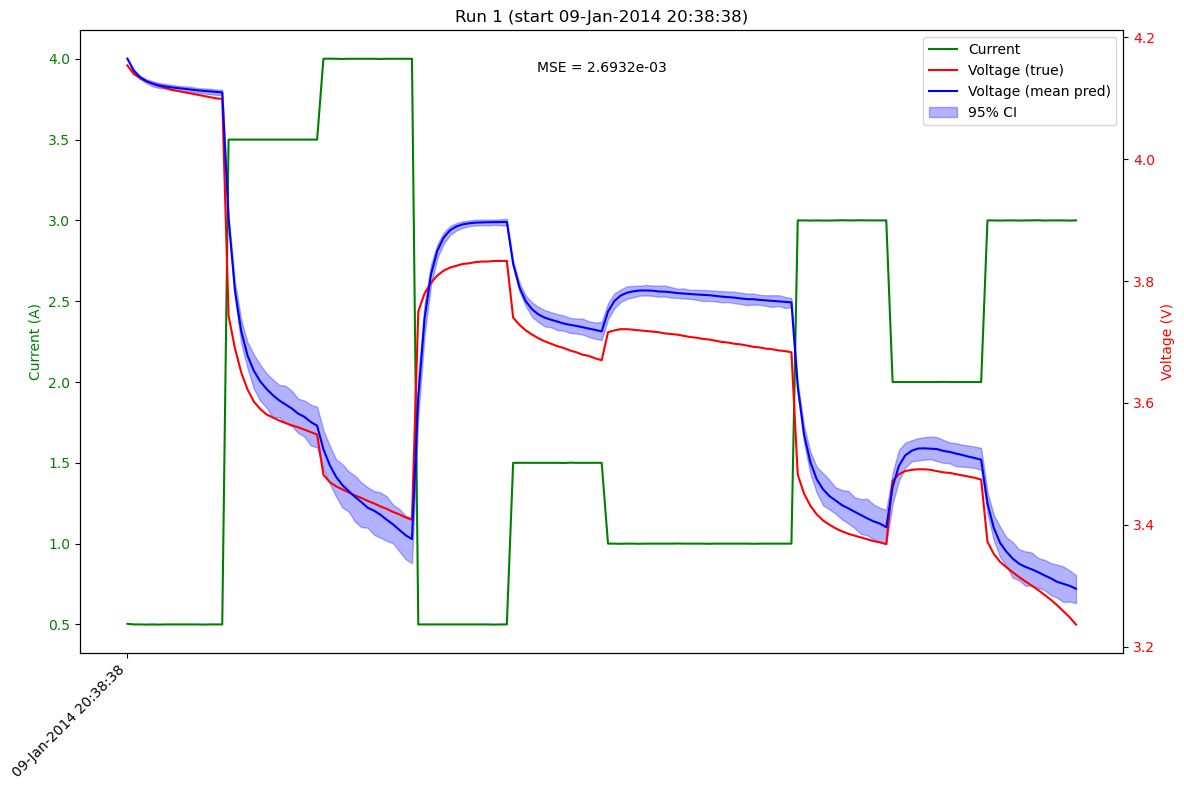

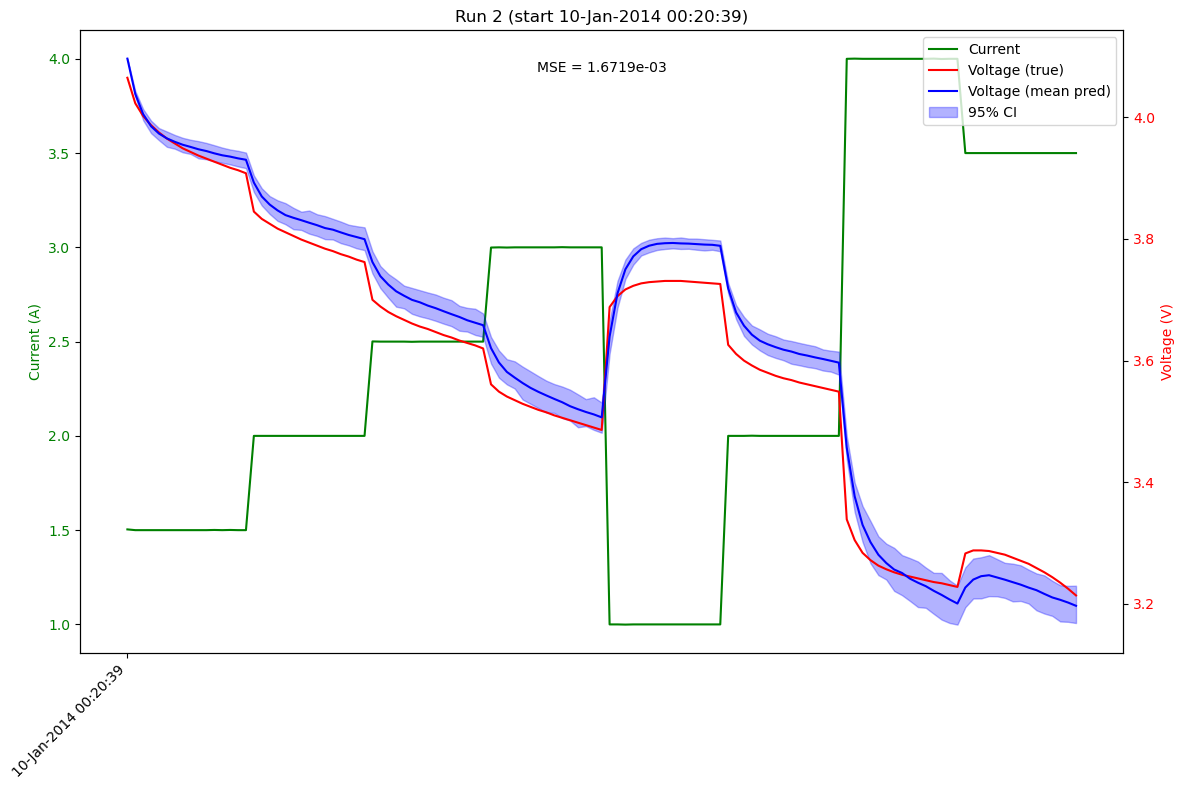

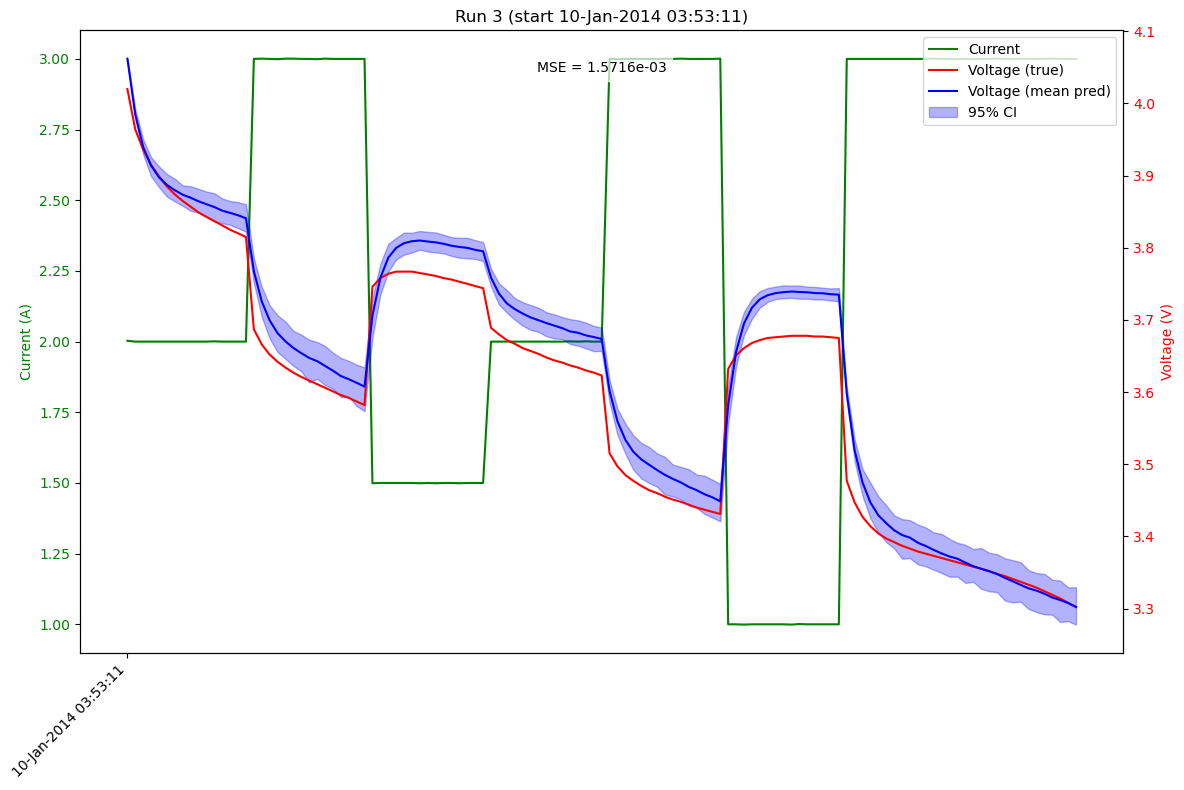

Testing on 686 runs
Test error [MAE, MAPE, MSE, RMSE]: [0.14245671033859253, 0.040366604924201965, 0.02724466472864151, 0.15128973126411438]
Test error [MAE, MAPE, MSE, RMSE]: [0.14245671033859253, 0.040366604924201965, 0.02724466472864151, 0.15128973126411438]


In [4]:
def get_args():
    parser = argparse.ArgumentParser(description='Battery Net for NPZData')
    # — Original battery‐model params —
    parser.add_argument('--V0',        type=float, default=4.2)
    parser.add_argument('--x0',        nargs=3,   type=float, default=[8000, 0, 0])
    parser.add_argument('--dt',        type=float, default=1.0)
    parser.add_argument('--VEOD',      type=float, default=3.2)
    parser.add_argument('--Rp',        type=float, default=1000)
    parser.add_argument('--Rs',        type=float, default=0.5)
    parser.add_argument('--Csp',       type=float, default=15)
    parser.add_argument('--Cs',        type=float, default=500)

    # — Training / data params —
    parser.add_argument('--batch_size', '-n', type=int,   default=60)
    parser.add_argument('--seq_len',    '-l', type=int,   default=30)
    parser.add_argument('--npz_dir',              default='../../dataset/')

    # — Optimization params —
    parser.add_argument('--device',     default='cpu')
    parser.add_argument('--epoch',      type=int,   default=500)
    parser.add_argument('--lr',         type=float, default=2e-2)
    parser.add_argument('--weight_decay',type=float,default=5e-4)

    # — Model selection & saving —
    parser.add_argument('--model_name', choices=['BattNN','LSTM'], default='BattNN')
    parser.add_argument('--save_model', choices=[None,'NASA'], default='NASA')

    # ignore Jupyter args
    args, _ = parser.parse_known_args()
    return args

# 1) Build args
args = get_args()
print("Arguments:", args)

# 3) Load data
data = NPZData(npz_dir=args.npz_dir,
               n=args.batch_size,
               length=args.seq_len)

train_x, train_y, train_dates = data.load_train_data()
print("Train shape:", train_x.shape, train_y.shape)

# 4) Train & test
model = train(args, train_x, train_y, model_name=args.model_name)

mean_error, errors = test(
    args,
    data_iter=data.yield_test_data,
    model_name=args.model_name,
    plot_n=3,
    mc_samples=200
)

np.savez(f'results/vBattNN-{args.save_model}-batch_size={args.batch_size}-seq_len={args.seq_len}.npz', errors)
print("Test error [MAE, MAPE, MSE, RMSE]:", mean_error)